In [1]:
import numpy as np
import sys
%load_ext autoreload
%autoreload 2
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/chainedQR/EnergyFlow/")
from energyflow.archs import EFN, PFN
import matplotlib.pyplot as plt
import h5py
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/commonTools/")
import helper_functions as hf
import qRegNN_NFs_general as qrnn
import torch
import torch.nn as nn
device = torch.device('cuda:0')

In [2]:
def plotPair(ref,samples,weights,bins=50,log=False,ylim=[0,2]):
    plt.subplots(figsize=(8,6),nrows=2,ncols=1,gridspec_kw={'height_ratios':[3,1]},sharex=True)
    plt.subplot(211)
    h1,bins,_ = plt.hist(ref,bins=bins,
                         density=True,histtype='step',label=f'reference')
    h2,bins,_ = plt.hist(samples,bins=bins,weights=weights,
                        density=True,histtype='step',label=f'samples')
    if log:
        plt.yscale('log')
    plt.legend()
    plt.subplot(212)
    w = bins[1]-bins[0]
    c = (bins[1:]+bins[:-1])/2
    h = np.divide(h2,h1,where=h1>0)
    plt.bar(x=c,height=h,width=w,align='center')
    if ylim is not None:
        plt.ylim(ylim)
        plt.yticks(np.linspace(ylim[0],ylim[1],5))
    else:
        plt.ylim([0.8,1.2])
        plt.yticks(np.arange(0.8,1.3,0.1))
    plt.grid(axis='y')
    plt.ylabel("Ratio")
    
def triplet(ref,uncorr,weights,axes,names,colors,bins=50,xlim=None):
    plt.sca(axes[0])
    h1,bins,_ = plt.hist(ref,bins=bins,histtype='step',label=names[0],density=True,color=colors[0],fill=True,alpha=0.5)
    h3,bins,_ = plt.hist(uncorr,bins=bins,histtype='step',label=names[1],density=True,color=colors[1],linewidth=3)
    h2,bins,_ = plt.hist(uncorr,weights=weights,bins=bins,histtype='step',label=names[2],density=True,color=colors[2],linewidth=3)
    h1c,bins = np.histogram(ref,bins=bins)
    h3c,bins = np.histogram(uncorr,bins=bins)
    h2c,bins = np.histogram(uncorr,weights=weights,bins=bins)
    if xlim is not None:
        plt.xlim(xlim)
    plt.legend()
    plt.sca(axes[1])
    w = bins[1]-bins[0]
    c = (bins[1:]+bins[:-1])/2
    h = np.divide(h2,h1,where=h1>0)
    herr = np.abs(h)*np.sqrt(np.divide(1.0,h2c.astype(np.float32),out=np.zeros_like(h2c.astype(np.float32)),where=h2c>0) + np.divide(1.0,h1c.astype(np.float32),out=np.zeros_like(h1c.astype(np.float32)),where=h1c>0))
    plt.errorbar(c,h,yerr=herr,color=colors[2],linewidth=0,markersize=15,marker='.',elinewidth=2,capsize=3,capthick=2)
    h = np.divide(h3,h1,where=h1>0)
    herr = np.abs(h)*np.sqrt(np.divide(1.0,h3c.astype(np.float32),out=np.zeros_like(h3c.astype(np.float32)),where=h3c>0) + np.divide(1.0,h1c.astype(np.float32),out=np.zeros_like(h1c.astype(np.float32)),where=h1c>0))
    plt.errorbar(c,h,yerr=herr,color=colors[1],linewidth=0,markersize=15,marker='.',elinewidth=2,capsize=3,capthick=2)
    if xlim is not None:
        plt.xlim(xlim)
    plt.ylim([0,2])
    plt.yticks(np.arange(0,2.5,0.5))
    plt.grid(axis='y')

# Try with 8d jet1/jet2 space

In [3]:
base = "/nobackup/users/sambt/QR_samples/LHCO/"
f_bb1 = f"{base}/challenge/BB1/merged.h5"
f_ind_bb1 = f"{base}/challenge/BB1/split_indices.h5"
f_rd = f"{base}/rd/RD/merged.h5"
f_ind_rd = f"{base}/rd/RD/split_indices.h5"


fitvars = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43',
           'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43']

with h5py.File(f_ind_rd,'r') as f:
    rd_test_idx = f['test_inds'][()]
    rd_train_idx = f['train_inds'][()]
    rd_val_idx = f['val_inds'][()]
    
with h5py.File(f_ind_bb1,'r') as f:
    bb1_test_idx = f['test_inds'][()]
    bb1_train_idx = f['train_inds'][()]
    bb1_val_idx = f['val_inds'][()]
    
with h5py.File(f_bb1,"r") as fp_b1:
    labels_b1 = np.loadtxt(f"{base}/challenge/BB1/events_LHCO2020_BlackBox1.masterkey")
    b1_test = np.concatenate([fp_b1[v][()][labels_b1==0].reshape(-1,1) for v in fitvars],axis=1)[bb1_test_idx]
    b1_train = np.concatenate([fp_b1[v][()][labels_b1==0].reshape(-1,1) for v in fitvars],axis=1)[bb1_train_idx]
    b1_val = np.concatenate([fp_b1[v][()][labels_b1==0].reshape(-1,1) for v in fitvars],axis=1)[bb1_val_idx]
    
with h5py.File(f_rd,"r") as frd:
    label = frd['label'][()]
    mask = label==0
    rd_test = np.concatenate([frd[v][()][mask].reshape(-1,1) for v in fitvars],axis=1)[rd_test_idx]
    rd_train = np.concatenate([frd[v][()][mask].reshape(-1,1) for v in fitvars],axis=1)[rd_train_idx]
    rd_val = np.concatenate([frd[v][()][mask].reshape(-1,1) for v in fitvars],axis=1)[rd_val_idx]

In [4]:
train = np.concatenate((rd_train,b1_train),axis=0)
train_lab = np.concatenate((np.zeros((rd_train.shape[0],1)),np.ones((b1_train.shape[0],1))),axis=0)
p = np.random.permutation(np.arange(train.shape[0]))
train,train_lab = train[p],train_lab[p]

test = np.concatenate((rd_test,b1_test),axis=0)
test_lab = np.concatenate((np.zeros((rd_test.shape[0],1)),np.ones((b1_test.shape[0],1))),axis=0)
p = np.random.permutation(np.arange(test.shape[0]))
test,test_lab = test[p],test_lab[p]

val = np.concatenate((rd_val,b1_val),axis=0)
val_lab = np.concatenate((np.zeros((rd_val.shape[0],1)),np.ones((b1_val.shape[0],1))),axis=0)
p = np.random.permutation(np.arange(val.shape[0]))
val,val_lab = val[p],val_lab[p]

mean, std = train.mean(axis=0), train.std(axis=0)
train = (train-mean)/std
test = (test-mean)/std
val = (val-mean)/std
with h5py.File("reweighting_methods/HL_meanStd_dnn.h5","w") as f:
    f.create_dataset("mean",data=mean)
    f.create_dataset("std",data=std)

Loss: 0.6791596412658691, p = 4872: 100%|██████████| 14642/14642 [06:01<00:00, 40.55it/s] 


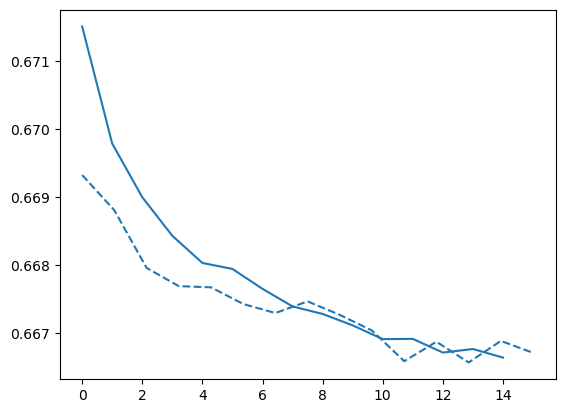

In [6]:
n_in = train.shape[1]
n_hidden = 128
num_hidden = 6
n_out = 1
act = nn.ReLU()
out_act = nn.Sigmoid()

net1 = qrnn.NeuralNet(n_in, n_hidden, n_out, num_hidden, act=act, out_act=out_act,dropout=0.1)

net1,loss,val_loss = qrnn.train_nn(net1,train,train_lab,val,val_lab,n_epoch=15,lr=5e-4,bs=1024,lossfunc="BCE",plot=False,losses=True)

plt.plot(np.arange(len(loss)),loss,color=f"C0")
plt.plot(np.linspace(0,len(loss),len(val_loss)),val_loss,color=f"C0",linestyle='--')

AUC = 0.6300863539438971


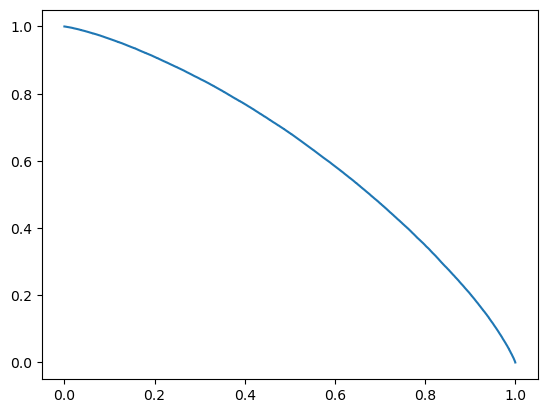

In [5]:
with torch.no_grad():
    preds = net1(torch.tensor(test,dtype=torch.float32,device='cpu')).detach().cpu().numpy()
from sklearn.metrics import roc_auc_score, roc_curve
auc = roc_auc_score(test_lab,preds)
fpr,tpr,thresh = roc_curve(test_lab,preds)
plt.plot(tpr,1-fpr)
print(f"AUC = {auc}")

In [7]:
torch.save(net1,"reweighting_methods/dnn_jets12_highLevel_toReweightRD.pt")

In [7]:
weights = preds[:,0]/(1-preds[:,0])

In [9]:
wgt_rd = weights[test_lab[:,0]==0]

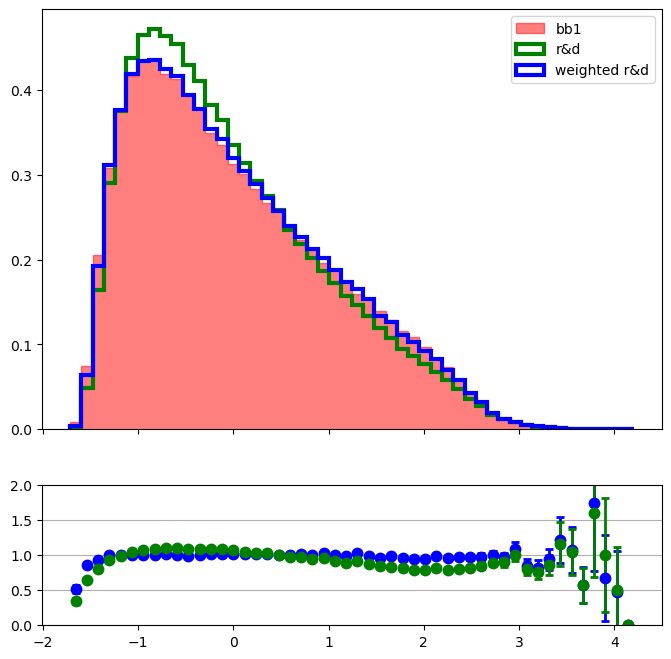

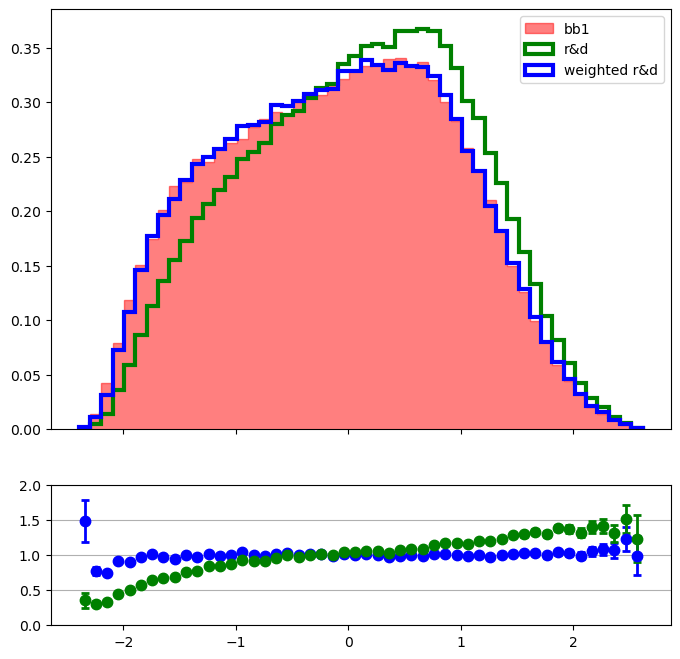

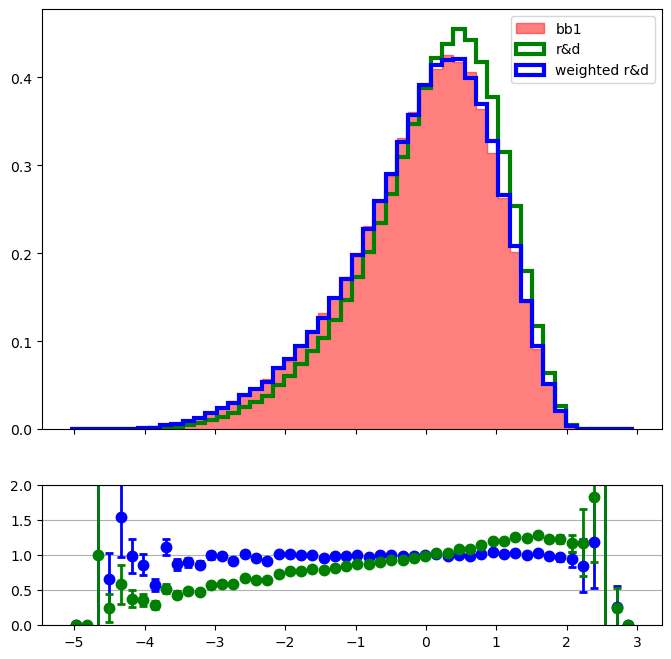

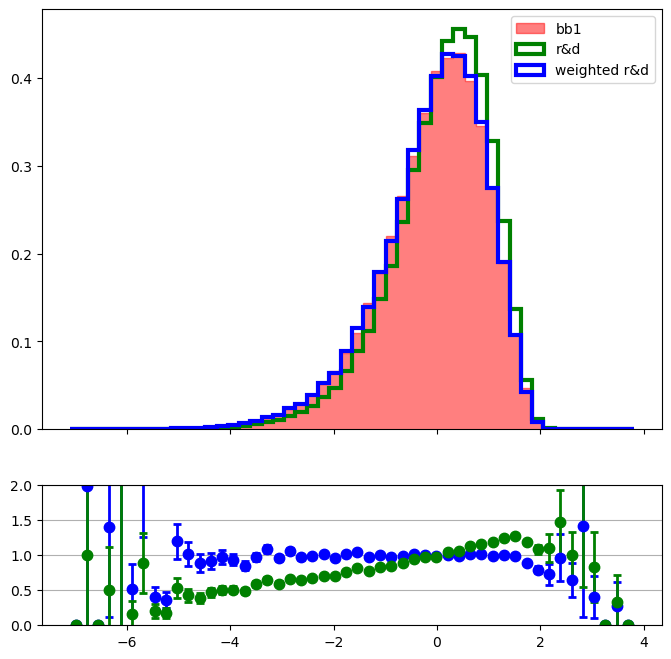

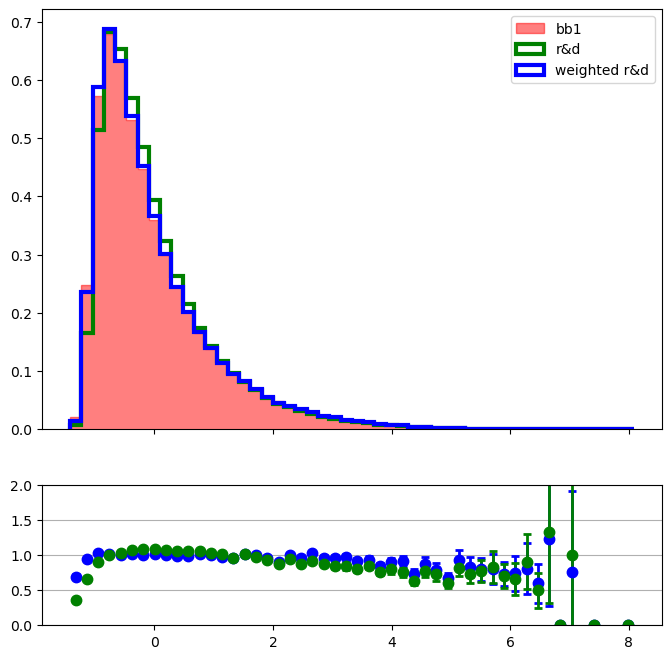

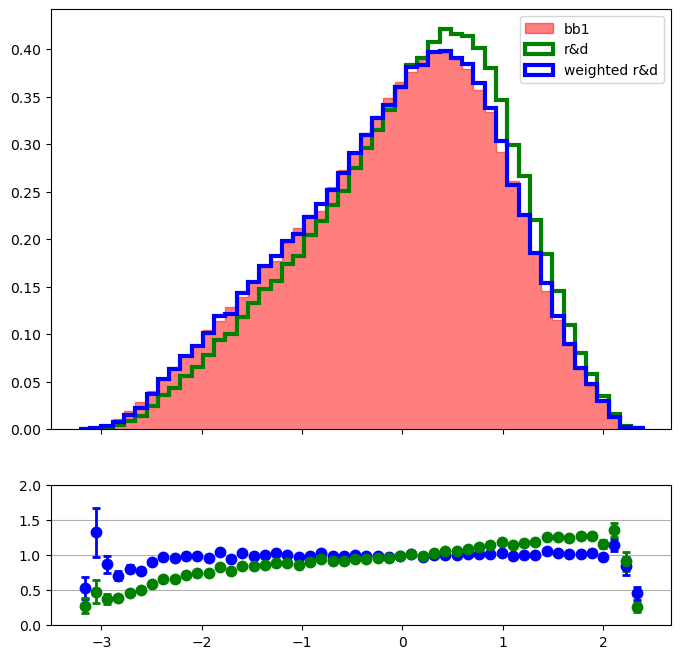

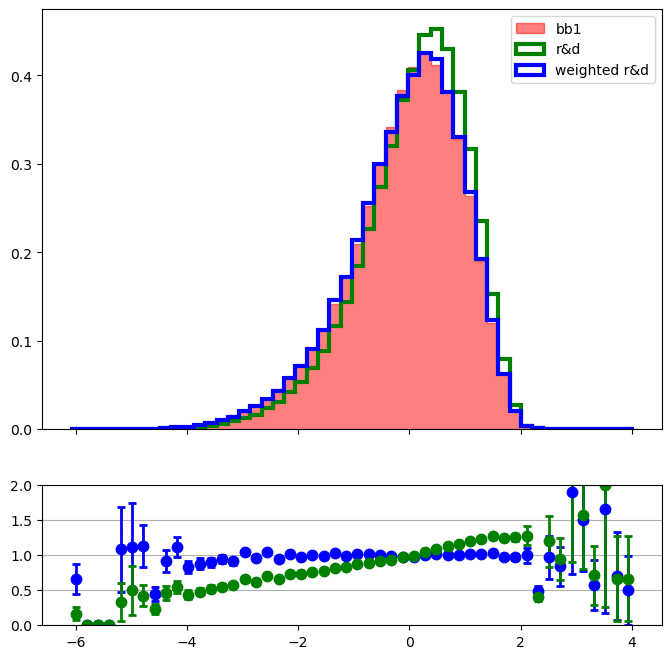

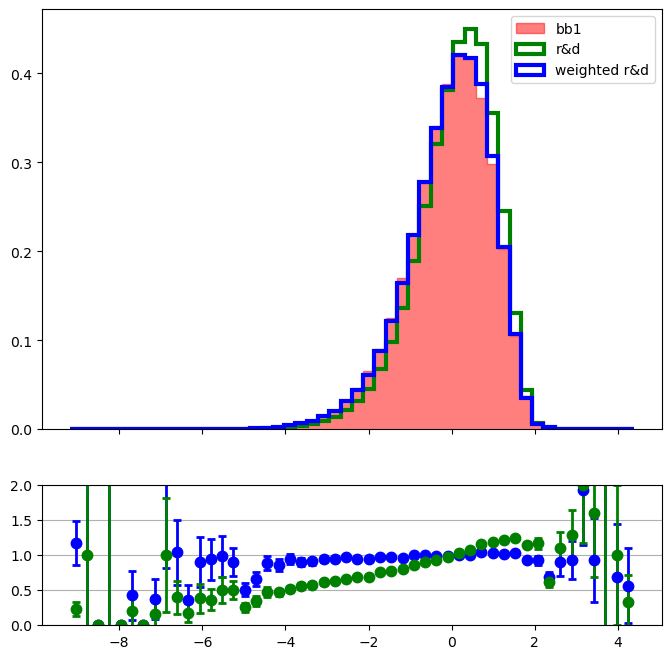

In [10]:
for i in range(test.shape[1]):
    fig,axes = plt.subplots(figsize=(8,8),nrows=2,ncols=1,gridspec_kw={'height_ratios':[3,1]},sharex=True)
    triplet(test[:,i][test_lab[:,0]==1],test[:,i][test_lab[:,0]==0],wgt_rd,axes,names=['bb1','r&d','weighted r&d'],colors=['r','g','b'])

# Try with particlenet + high-dim inputs
Same setup as https://arxiv.org/pdf/1907.08209.pdf

In [2]:
from sklearn.metrics import roc_auc_score, roc_curve

def train_efn(train,test,val,efn_kwargs,train_kwargs,plot=True):
    X_train, Y_train = train
    X_test, Y_test = test
    X_val, Y_val = val
    
    z_train, z_test, z_val = X_train[:,:,0], X_test[:,:,0], X_val[:,:,0]
    p_train, p_test, p_val = X_train[:,:,1:], X_test[:,:,1:], X_val[:,:,1:]

    efn = EFN(**efn_kwargs)
    
    hist = efn.fit([z_train, p_train], Y_train,
            validation_data=([z_val, p_val], Y_val),
           **train_kwargs)
    
    plt.figure(figsize=(8,6))
    plt.plot(hist.history['loss'])
    plt.plot(hist.history['val_loss'])
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'val'], loc='upper left')
    
    preds = efn.predict([z_test, p_test], batch_size=1000)
    bce_loss = BinaryCrossentropy(from_logits=False)
    test_loss = bce_loss(Y_test,preds).numpy()
    print(f"Test Loss : {test_loss:.5f}")
    efn_fp, efn_tp, threshs = roc_curve(Y_test, preds[:,0])
    auc = roc_auc_score(Y_test, preds[:,0])
    print('EFN AUC:', auc)
    if plot:
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['figure.autolayout'] = True

        plt.figure(figsize=(10,10))
        plt.plot(efn_tp, 1-efn_fp, '-', color='black', label='EFN')
    
    del X_train,X_test,X_val,Y_train,Y_test,Y_val
    del z_train, z_val, z_test, p_train, p_val, p_test, preds
    del train, test, val
    
    return efn, auc, efn_fp, efn_tp, threshs

def train_pfn(train,test,val,pfn_kwargs,train_kwargs,plot=True):
    X_train, Y_train = train
    X_test, Y_test = test
    X_val, Y_val = val
    
    pfn = PFN(**pfn_kwargs)
    
    hist = pfn.fit(X_train, Y_train,
            validation_data=(X_val, Y_val),
           **train_kwargs)
    
    plt.figure(figsize=(8,6))
    plt.plot(hist.history['loss'])
    plt.plot(hist.history['val_loss'])
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'val'], loc='upper left')
    
    preds = pfn.predict(X_test, batch_size=1000)
    bce_loss = BinaryCrossentropy(from_logits=False)
    test_loss = bce_loss(Y_test,preds).numpy()
    print(f"Test Loss : {test_loss:.5f}")
    pfn_fp, pfn_tp, threshs = roc_curve(Y_test, preds[:,0])
    auc = roc_auc_score(Y_test, preds[:,0])
    print('pfn AUC:', auc)
    if plot:
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['figure.autolayout'] = True

        plt.figure(figsize=(10,10))
        plt.plot(pfn_tp, 1-pfn_fp, '-', color='black', label='pfn')
    
    del X_train,X_test,X_val,Y_train,Y_test,Y_val
    del train, test, val
    
    return pfn, auc, pfn_fp, pfn_tp, threshs

In [2]:
from edgeconv import EdgeConvBlock, ParticleNet
sys.path.append("quantiledatamc/auc95_pn_ctr/")
from run_pnet import simple_MLP, load_parts, PNetWrapper
pnet_classifier = torch.load("quantiledatamc/end_gpu_base_satori_full.pt").to(device)

In [3]:
bb1_ftrain = "/nobackup/users/sambt/QR_samples/LHCO/test/bkg_bb1_particleNet_sample.h5"
rd_ftrain = "/nobackup/users/sambt/QR_samples/LHCO/rd/RD/bkg_particleNet_sample.h5"
bb1_ftest = "/nobackup/users/sambt/QR_samples/LHCO/challenge/BB1/bkg_particleNet_test_sample.h5"
rd_ftest = "/nobackup/users/sambt/QR_samples/LHCO/rd/RD/bkg_particleNet_test_sample.h5"
b1_train = load_parts(bb1_ftrain,cutoff=False)
rd_train = load_parts(rd_ftrain,cutoff=False)
b1_test = load_parts(bb1_ftest,cutoff=False)
rd_test = load_parts(rd_ftest,cutoff=False)

with h5py.File("quantiledatamc/meanstd.h5","r") as f:
    tot1m = f['tot1m'][()]
    tot1s = f['tot1s'][()]

b1_train = (b1_train-tot1m)/tot1s
b1_test = (b1_test-tot1m)/tot1s
rd_train = (rd_train-tot1m)/tot1s
rd_test = (rd_test-tot1m)/tot1s

/nobackup/users/sambt/QR_samples/LHCO/test/bkg_bb1_particleNet_sample.h5 <KeysViewHDF5 ['ce', 'ceta', 'cphi', 'cpt', 'cz', 'cze', 'jet1_eta', 'jet1_m', 'jet1_phi', 'jet1_pt', 'jet1_tau21', 'jet1_tau32', 'jet1_tau43']>
/nobackup/users/sambt/QR_samples/LHCO/rd/RD/bkg_particleNet_sample.h5 <KeysViewHDF5 ['ce', 'ceta', 'cphi', 'cpt', 'cz', 'cze', 'jet1_eta', 'jet1_m', 'jet1_phi', 'jet1_pt', 'jet1_tau21', 'jet1_tau32', 'jet1_tau43']>
/nobackup/users/sambt/QR_samples/LHCO/challenge/BB1/bkg_particleNet_test_sample.h5 <KeysViewHDF5 ['ce', 'ceta', 'cphi', 'cpt', 'cz', 'cze', 'jet1_eta', 'jet1_m', 'jet1_phi', 'jet1_pt', 'jet1_tau21', 'jet1_tau32', 'jet1_tau43']>
/nobackup/users/sambt/QR_samples/LHCO/rd/RD/bkg_particleNet_test_sample.h5 <KeysViewHDF5 ['ce', 'ceta', 'cphi', 'cpt', 'cz', 'cze', 'jet1_eta', 'jet1_m', 'jet1_phi', 'jet1_pt', 'jet1_tau21', 'jet1_tau32', 'jet1_tau43']>


In [4]:
from sklearn.model_selection import train_test_split
b1_train,b1_val = train_test_split(b1_train,train_size=0.75)
rd_train,rd_val = train_test_split(rd_train,train_size=0.75)

train = np.concatenate((b1_train,rd_train),axis=0)
train_lab = np.concatenate((np.ones(b1_train.shape[0]),np.zeros(rd_train.shape[0]))).reshape(-1,1)
p = np.random.permutation(train.shape[0])
train,train_lab = train[p],train_lab[p]

test = np.concatenate((b1_test,rd_test),axis=0)
test_lab = np.concatenate((np.ones(b1_test.shape[0]),np.zeros(rd_test.shape[0]))).reshape(-1,1)
p = np.random.permutation(test.shape[0])
test,test_lab = test[p],test_lab[p]

val = np.concatenate((b1_val,rd_val),axis=0)
val_lab = np.concatenate((np.ones(b1_val.shape[0]),np.zeros(rd_val.shape[0]))).reshape(-1,1)
p = np.random.permutation(val.shape[0])
val,val_lab = val[p],val_lab[p]

In [5]:
# try with particlenet
pnet = PNetWrapper(train.shape[2],1,conv_params=[(8, (32, 32, 32)), (8, (64, 64, 64))],
            fc_params=[(128, 0.1)],use_fusion=False,use_fts_bn=False,use_counts=False,for_inference=False,for_segmentation=False,act_out=True)
pnet,loss,val_loss = qrnn.train_nn(pnet,train,train_lab,val,val_lab,
                                   n_epoch=50,lr=1e-4,bs=512,lossfunc="BCE",plot=False,losses=True)

Loss: 0.6323606371879578, p = 2919: 100%|██████████| 14648/14648 [10:14<00:00, 23.85it/s]


In [15]:
torch.save(pnet,"reweighting_methods/particlenet_rdVsBB1_toReweightRD.pt")

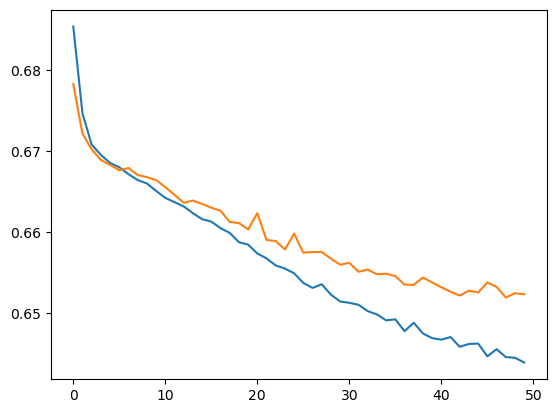

In [6]:
plt.plot(loss)
plt.plot(val_loss)

In [7]:
from sklearn.metrics import roc_auc_score, roc_curve
pnet = pnet.to(device)
with torch.no_grad():
    split = np.array_split(np.arange(len(test)),test.shape[0]//1000)
    preds = []
    for s in split:
        preds.append(pnet(torch.tensor(test[s],dtype=torch.float32,device=device)).detach().cpu().numpy())
preds = np.concatenate(preds,axis=0)[:,0]
auc = roc_auc_score(test_lab[:,0],preds)
print(f'auc = {auc}')

auc = 0.6596659845230612


In [8]:
pnet = pnet.to(device)
with torch.no_grad():
    split = np.array_split(np.arange(len(rd_test)),rd_test.shape[0]//1000)
    preds = []
    for s in split:
        preds.append(pnet(torch.tensor(rd_test[s],dtype=torch.float32,device=device)).detach().cpu().numpy())
preds = np.concatenate(preds,axis=0)[:,0]

/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  


In [9]:
wgts = preds/(1-preds)
#wgts[~np.isfinite(wgts)]=1

In [11]:
def load_hl(filename,vars,cutoff=False):
    h5file = h5py.File(filename, 'r') # open read-only
    print(h5file.keys())
    out = []
    for v in vars:
        out.append(h5file[v][()].reshape(-1,1))
    return np.concatenate(out,axis=1)
vars = ['jet1_pt','jet1_m','jet1_tau21','jet1_tau32','jet1_tau43']
vars_b1 = load_hl(bb1_ftest,vars)
vars_rd = load_hl(rd_ftest,vars)
rho_b1 = vars_b1[:,1]/vars_b1[:,0]
rho_rd = vars_rd[:,1]/vars_rd[:,0]

<KeysViewHDF5 ['ce', 'ceta', 'cphi', 'cpt', 'cz', 'cze', 'jet1_eta', 'jet1_m', 'jet1_phi', 'jet1_pt', 'jet1_tau21', 'jet1_tau32', 'jet1_tau43']>
<KeysViewHDF5 ['ce', 'ceta', 'cphi', 'cpt', 'cz', 'cze', 'jet1_eta', 'jet1_m', 'jet1_phi', 'jet1_pt', 'jet1_tau21', 'jet1_tau32', 'jet1_tau43']>


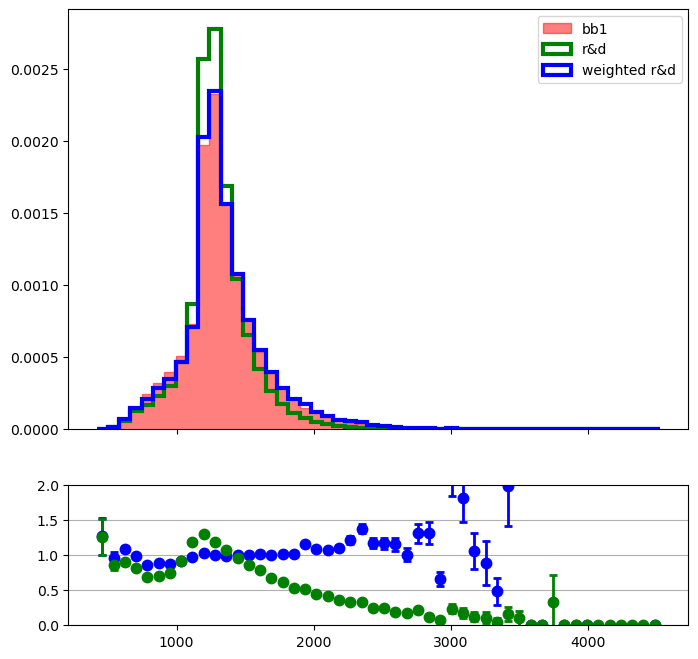

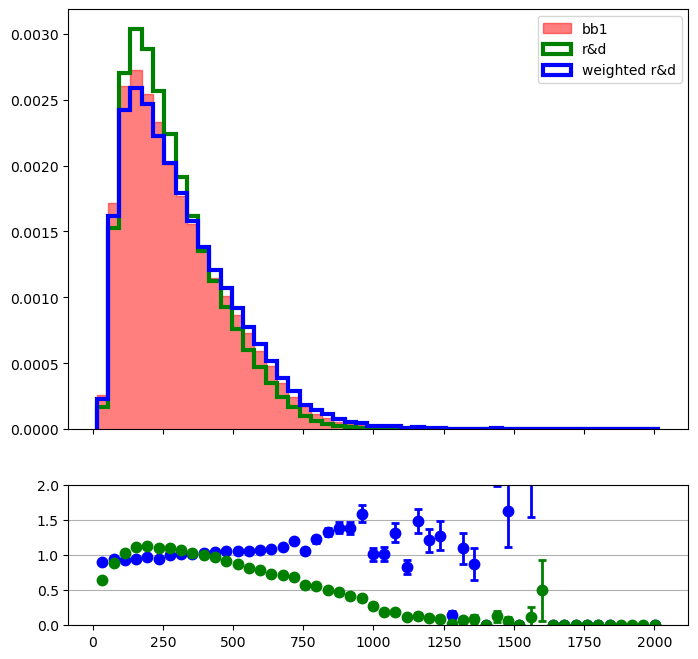

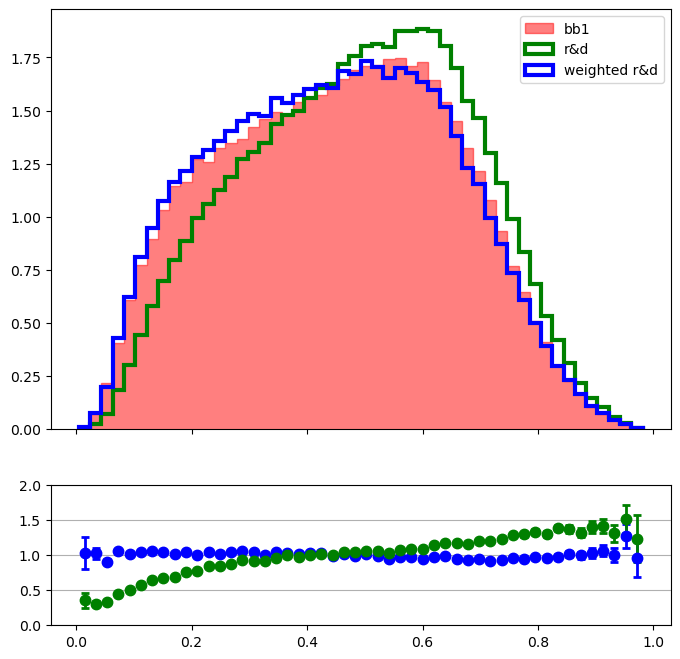

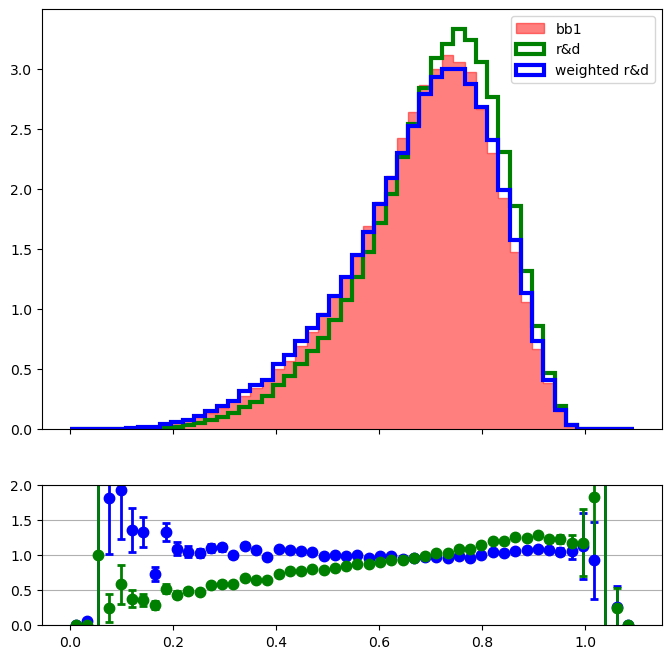

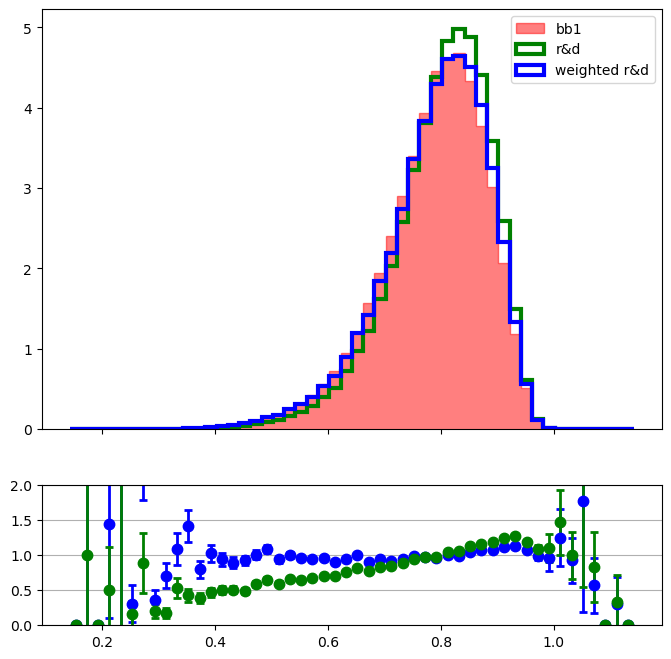

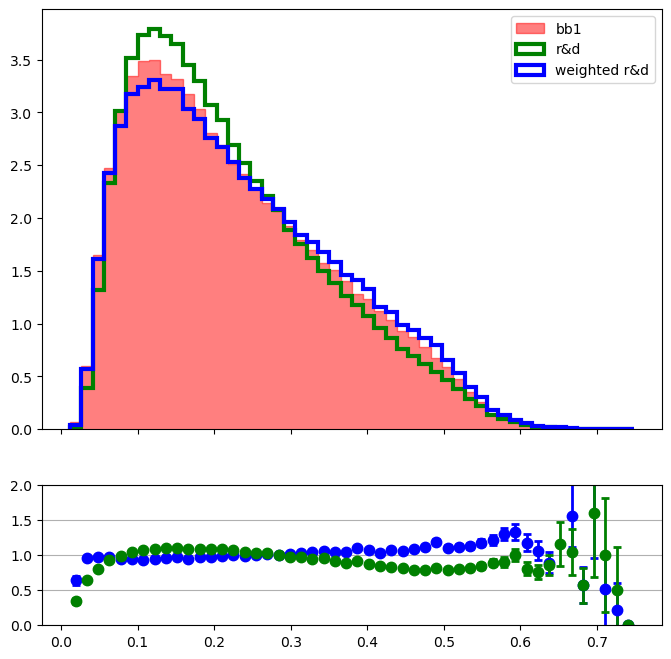

In [14]:
for i in range(vars_b1.shape[1]):
    fig,axes = plt.subplots(figsize=(8,8),nrows=2,ncols=1,gridspec_kw={'height_ratios':[3,1]},sharex=True)
    triplet(vars_b1[:,i],vars_rd[:,i],wgts,axes,names=['bb1','r&d','weighted r&d'],colors=['r','g','b'])
fig,axes = plt.subplots(figsize=(8,8),nrows=2,ncols=1,gridspec_kw={'height_ratios':[3,1]},sharex=True)
triplet(rho_b1,rho_rd,wgts,axes,names=['bb1','r&d','weighted r&d'],colors=['r','g','b'])

# Train in mass sideband

In [3]:
base = "/nobackup/users/sambt/QR_samples/LHCO/"
f_bb1 = f"{base}/challenge/BB1/merged.h5"
f_ind_bb1 = f"{base}/challenge/BB1/split_indices.h5"
f_rd = f"{base}/rd/RD/merged.h5"
f_ind_rd = f"{base}/rd/RD/split_indices.h5"

fitvars = ['mjj', # adding mjj for cutting on & conditioning flow
           'jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43',
           'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43']

sr_window = [3300,3700] # constructed around the 3.5 TeV Z' -> XY resonance from R&D dataset

with h5py.File(f_ind_rd,'r') as f:
    rd_test_idx = f['test_inds'][()]
    rd_train_idx = f['train_inds'][()]
    rd_val_idx = f['val_inds'][()]
    
with h5py.File(f_ind_bb1,'r') as f:
    bb1_test_idx = f['test_inds'][()]
    bb1_train_idx = f['train_inds'][()]
    bb1_val_idx = f['val_inds'][()]
    
with h5py.File(f_bb1,"r") as fp_b1:
    labels_b1 = np.loadtxt(f"{base}/challenge/BB1/events_LHCO2020_BlackBox1.masterkey")
    nev = len(labels_b1)
    b1_test = np.concatenate([fp_b1[v][()][labels_b1==0].reshape(-1,1) for v in fitvars],axis=1)[bb1_test_idx]
    b1_test = b1_test[(b1_test[:,0]<sr_window[0])|(b1_test[:,0]>sr_window[1])]
    b1_train = np.concatenate([fp_b1[v][()][labels_b1==0].reshape(-1,1) for v in fitvars],axis=1)[bb1_train_idx]
    b1_train = b1_train[(b1_train[:,0]<sr_window[0])|(b1_train[:,0]>sr_window[1])]
    b1_val = np.concatenate([fp_b1[v][()][labels_b1==0].reshape(-1,1) for v in fitvars],axis=1)[bb1_val_idx]
    b1_val = b1_val[(b1_val[:,0]<sr_window[0])|(b1_val[:,0]>sr_window[1])]
    
    
with h5py.File(f_rd,"r") as frd:
    label = frd['label'][()]
    mask = label==0
    rd_test = np.concatenate([frd[v][()][mask].reshape(-1,1) for v in fitvars],axis=1)[rd_test_idx]
    rd_test = rd_test[(rd_test[:,0]<sr_window[0])|(rd_test[:,0]>sr_window[1])]
    rd_train = np.concatenate([frd[v][()][mask].reshape(-1,1) for v in fitvars],axis=1)[rd_train_idx]
    rd_train = rd_train[(rd_train[:,0]<sr_window[0])|(rd_train[:,0]>sr_window[1])]
    rd_val = np.concatenate([frd[v][()][mask].reshape(-1,1) for v in fitvars],axis=1)[rd_val_idx]
    rd_val = rd_val[(rd_val[:,0]<sr_window[0])|(rd_val[:,0]>sr_window[1])]

In [4]:
train = np.concatenate((rd_train,b1_train),axis=0)
train_lab = np.concatenate((np.zeros((rd_train.shape[0],1)),np.ones((b1_train.shape[0],1))),axis=0)
p = np.random.permutation(np.arange(train.shape[0]))
train,train_lab = train[p],train_lab[p]

test = np.concatenate((rd_test,b1_test),axis=0)
test_lab = np.concatenate((np.zeros((rd_test.shape[0],1)),np.ones((b1_test.shape[0],1))),axis=0)
p = np.random.permutation(np.arange(test.shape[0]))
test,test_lab = test[p],test_lab[p]

val = np.concatenate((rd_val,b1_val),axis=0)
val_lab = np.concatenate((np.zeros((rd_val.shape[0],1)),np.ones((b1_val.shape[0],1))),axis=0)
p = np.random.permutation(np.arange(val.shape[0]))
val,val_lab = val[p],val_lab[p]

mean, std = train.mean(axis=0), train.std(axis=0)
train = (train-mean)/std
test = (test-mean)/std
val = (val-mean)/std
with h5py.File("reweighting_methods/HL_meanStd_dnn_mjjSideband.h5","w") as f:
    f.create_dataset("mean",data=mean)
    f.create_dataset("std",data=std)

Loss: 0.648672878742218, p = 844: 100%|██████████| 12870/12870 [05:17<00:00, 40.48it/s]  


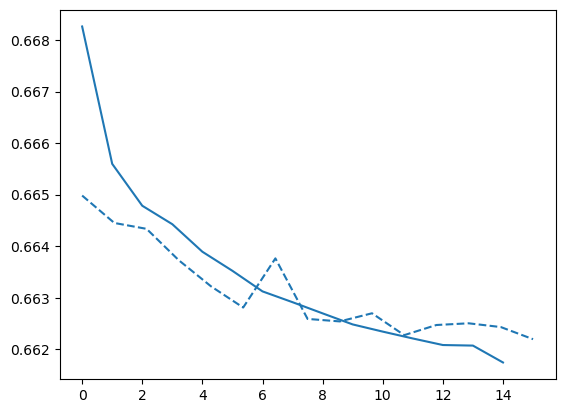

In [6]:
n_in = train.shape[1]
n_hidden = 128
num_hidden = 6
n_out = 1
act = nn.ReLU()
out_act = nn.Sigmoid()

net1 = qrnn.NeuralNet(n_in, n_hidden, n_out, num_hidden, act=act, out_act=out_act,dropout=0.1)

net1,loss,val_loss = qrnn.train_nn(net1,train,train_lab,val,val_lab,n_epoch=15,lr=5e-4,bs=1024,lossfunc="BCE",plot=False,losses=True)

plt.plot(np.arange(len(loss)),loss,color=f"C0")
plt.plot(np.linspace(0,len(loss),len(val_loss)),val_loss,color=f"C0",linestyle='--')

AUC = 0.6412313964517803


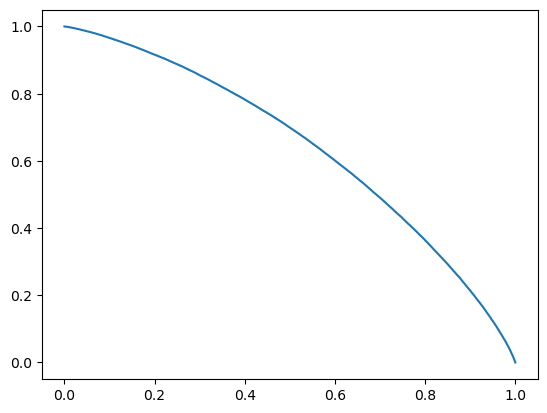

In [7]:
with torch.no_grad():
    preds = net1(torch.tensor(test,dtype=torch.float32,device='cpu')).detach().cpu().numpy()
from sklearn.metrics import roc_auc_score, roc_curve
auc = roc_auc_score(test_lab,preds)
fpr,tpr,thresh = roc_curve(test_lab,preds)
plt.plot(tpr,1-fpr)
print(f"AUC = {auc}")

In [8]:
torch.save(net1,"reweighting_methods/dnn_jets12_highLevel_toReweightRD_mjjSideband.pt")

In [9]:
weights = preds[:,0]/(1-preds[:,0])

In [10]:
wgt_rd = weights[test_lab[:,0]==0]

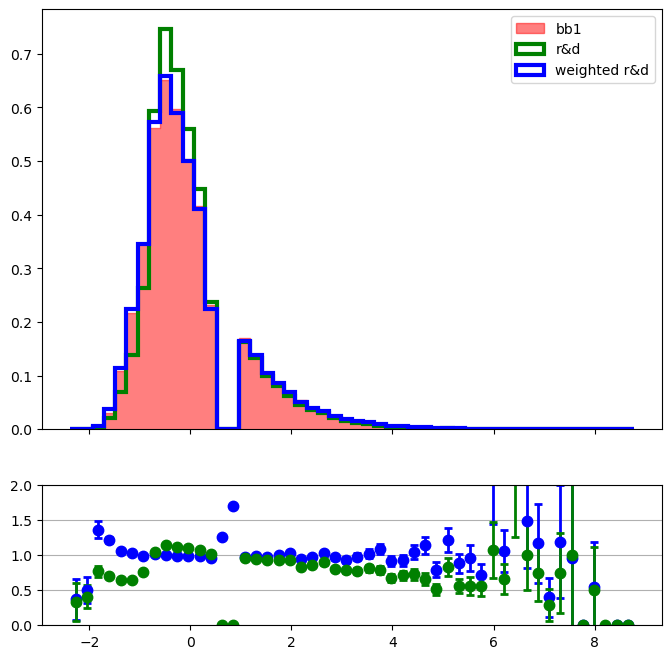

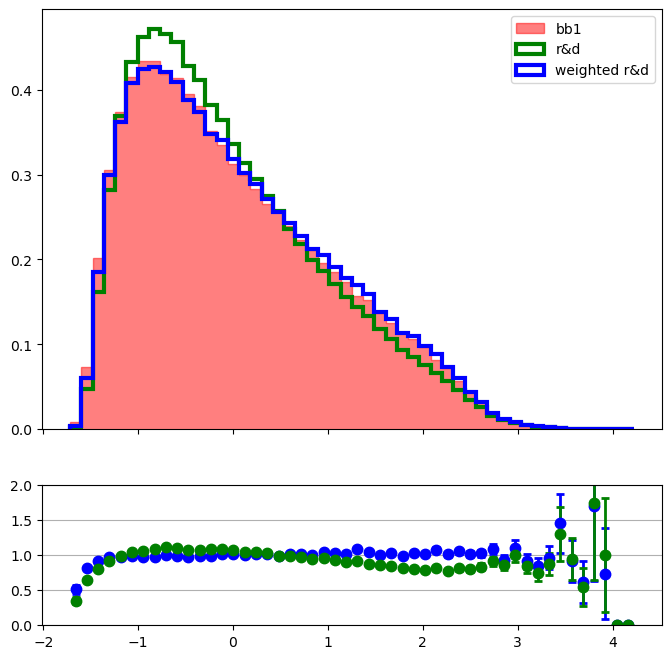

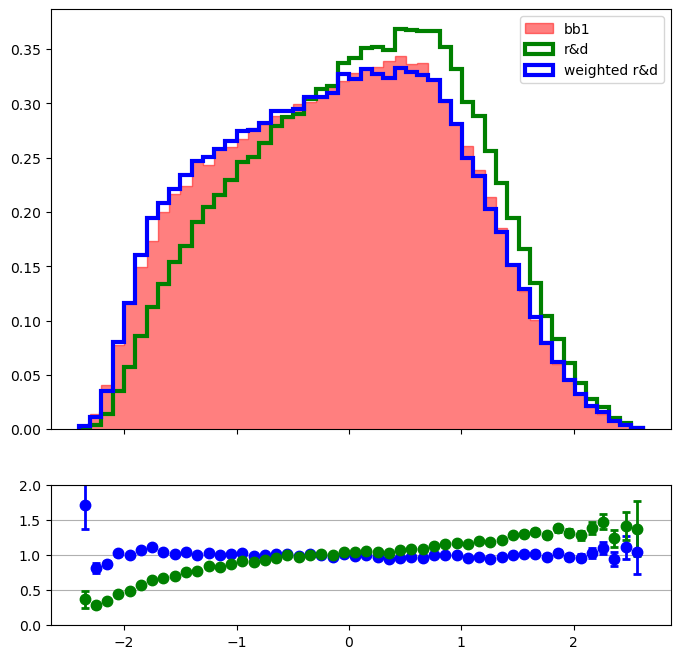

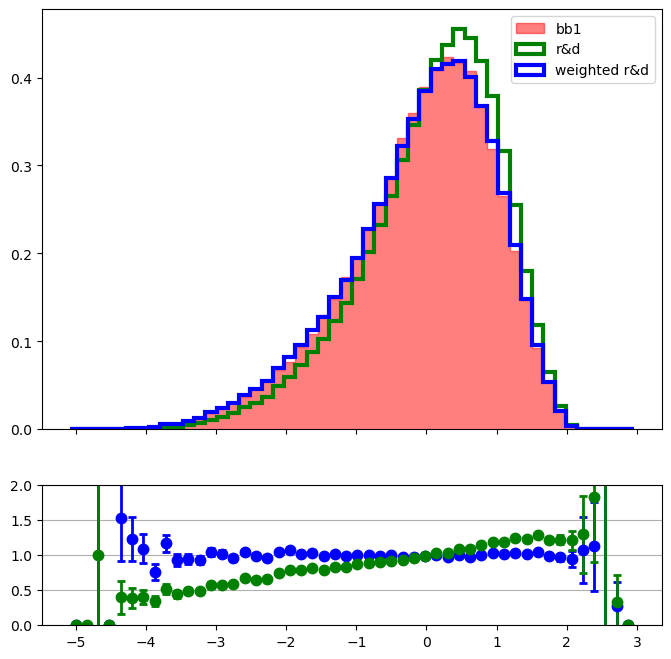

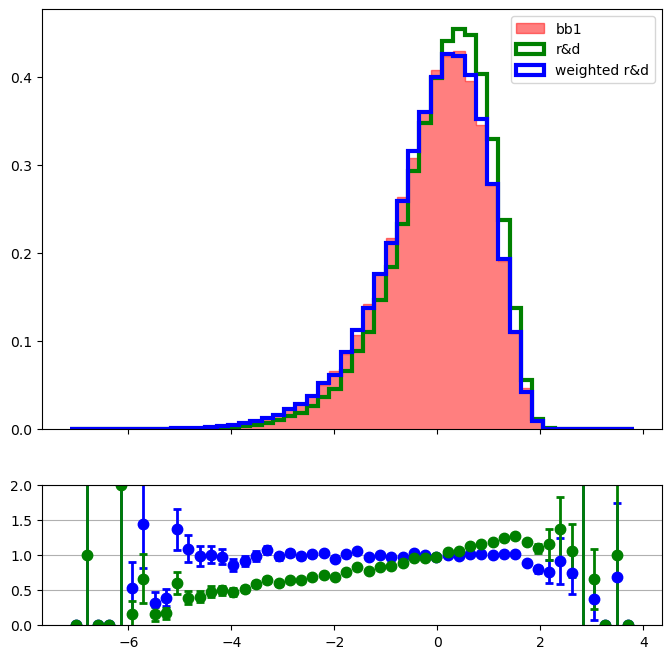

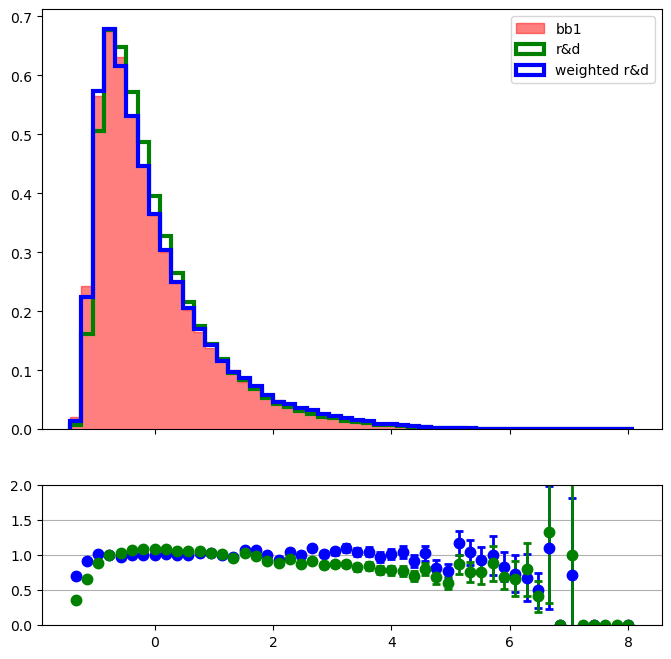

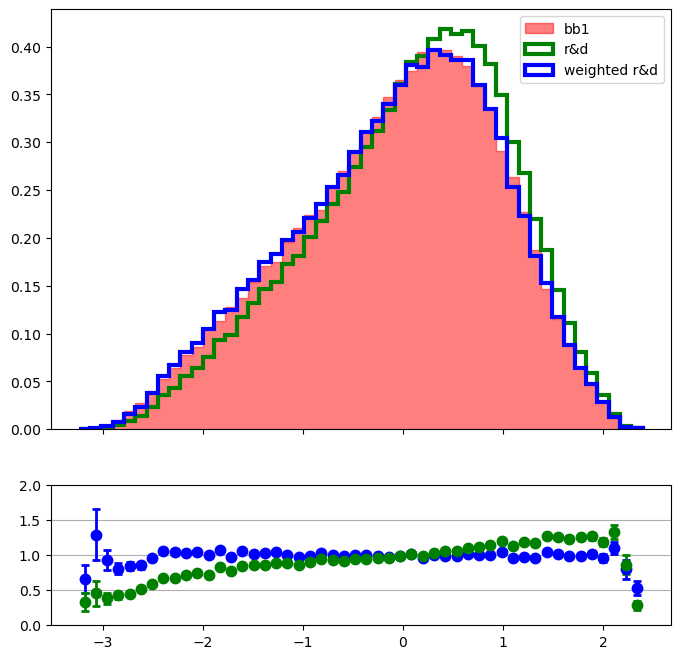

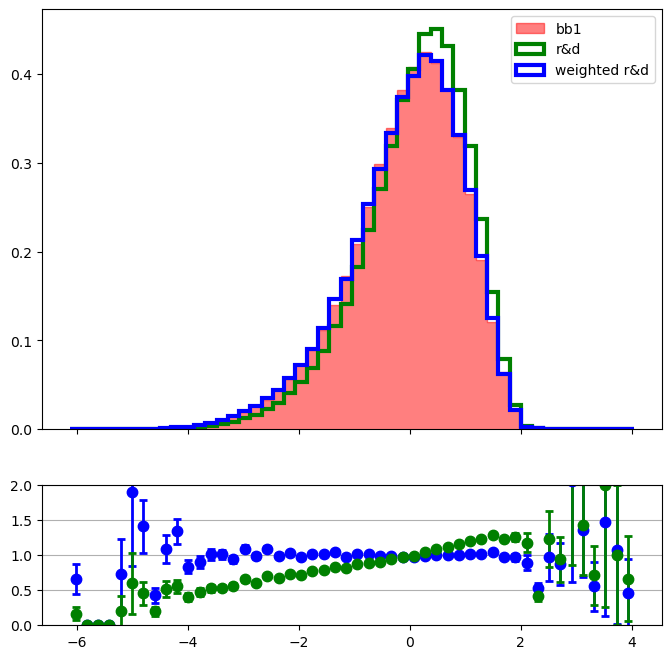

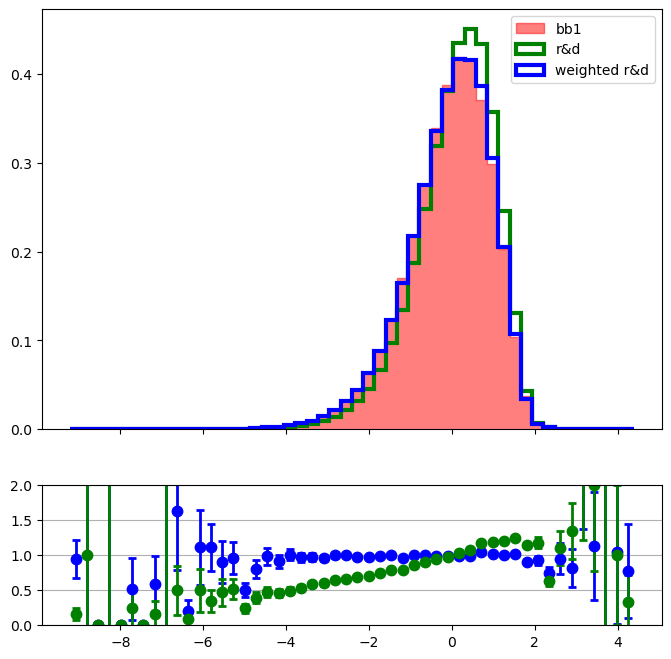

In [11]:
for i in range(test.shape[1]):
    fig,axes = plt.subplots(figsize=(8,8),nrows=2,ncols=1,gridspec_kw={'height_ratios':[3,1]},sharex=True)
    triplet(test[:,i][test_lab[:,0]==1],test[:,i][test_lab[:,0]==0],wgt_rd,axes,names=['bb1','r&d','weighted r&d'],colors=['r','g','b'])